<a href="https://colab.research.google.com/github/OumaymaAbayed/Concrete-Strength-Prediction-with-Neural-Networks/blob/main/NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Artificial Neural Networks

## Data Collecting & Exploring

In [1]:
concrete <-read.csv("concrete_data.csv")
str(concrete)

'data.frame':	1030 obs. of  9 variables:
 $ cement                       : num  540 540 332 332 199 ...
 $ blast_furnace_slag           : num  0 0 142 142 132 ...
 $ fly_ash                      : num  0 0 0 0 0 0 0 0 0 0 ...
 $ water                        : num  162 162 228 228 192 228 228 228 228 228 ...
 $ superplasticizer             : num  2.5 2.5 0 0 0 0 0 0 0 0 ...
 $ coarse_aggregate             : num  1040 1055 932 932 978 ...
 $ fine_aggregate               : num  676 676 594 594 826 ...
 $ age                          : num  28 28 270 365 360 90 365 28 28 28 ...
 $ concrete_compressive_strength: num  80 61.9 40.3 41 44.3 ...


In [26]:
# Testing for NA values
sum(is.na(concrete))


[1] 0

In [3]:
normalize <- function(x) {
 return((x - min(x)) / (max(x) - min(x)))
 }
concrete_norm <- as.data.frame(lapply(concrete, normalize))
summary(concrete_norm$concrete_compressive_strength)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.2664  0.4001  0.4172  0.5457  1.0000 

In [5]:
summary(concrete$concrete_compressive_strength)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2.33   23.71   34.45   35.82   46.13   82.60 

## Data Partition

we will partition
the data into a training set with 75 percent of the examples and a testing set with 25
percent.

In [32]:
concrete_train <- concrete_norm[1:773, ]
concrete_test <-concrete_norm[774:1030, ]

## Model Training
To model the relationship between the ingredients used in concrete and the strength of the finished product, we will use a multilayer feedforward neural network.

In [29]:
install.packages("neuralnet")
library(neuralnet)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [33]:
concrete_model <- neuralnet(concrete_compressive_strength ~ cement + blast_furnace_slag + fly_ash + water + superplasticizer + coarse_aggregate + fine_aggregate + age, data = concrete_train)

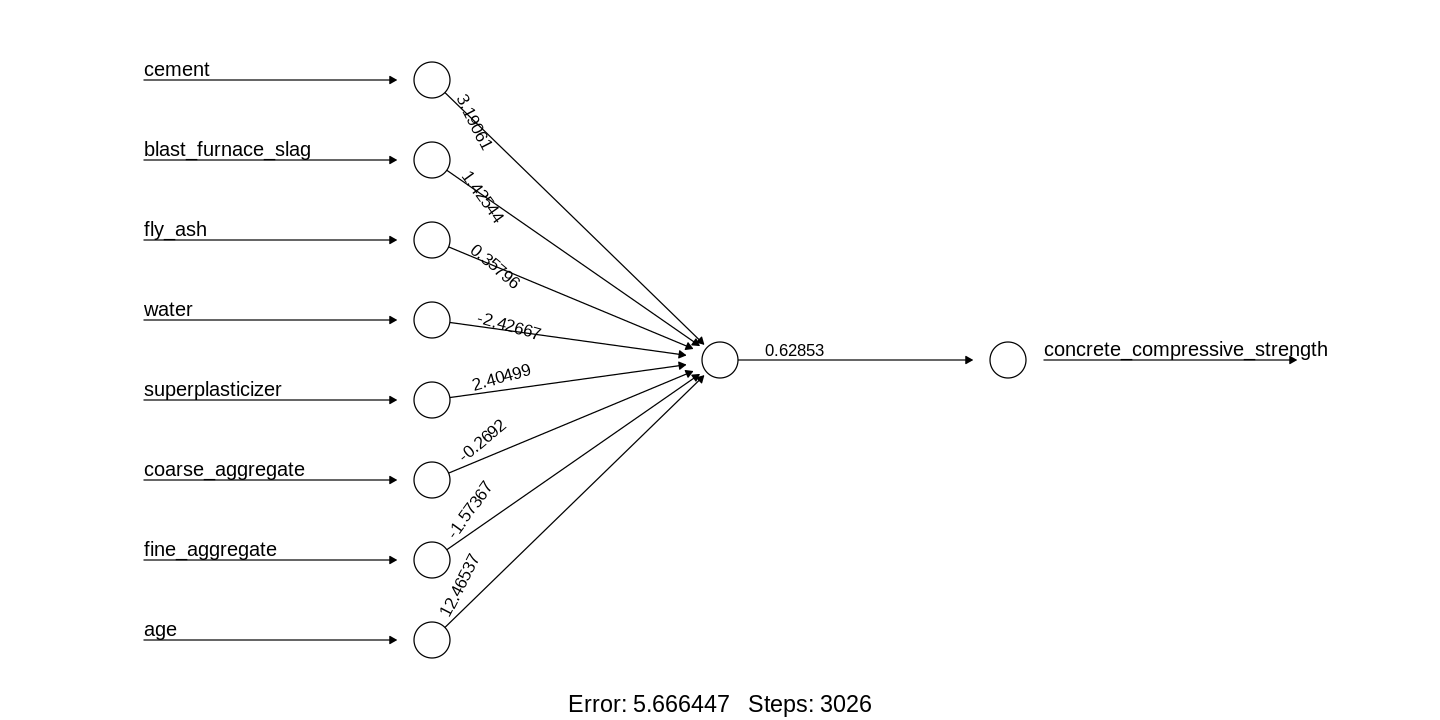

In [34]:
# Set plot size for inline display
options(repr.plot.width = 12, repr.plot.height = 6)

plot(concrete_model,
     rep = "best",         # Plots the best repetition if multiple were trained
     intercept = FALSE,    # Removes bias nodes if you want a simpler view
     show.weights = TRUE,  # Displays weights on the connections
     information = TRUE)   # Adds additional training info in the plot


In this simple model, there is:
-  one input node for each of the eight features
- a single hidden node
- a single output node that predicts the concrete strength.

The weights for each of the connections are also mentionned above the arrows.

## Model Evaluation

In [35]:
model_results <- compute(concrete_model, concrete_test[1:8])
predicted_strength <- model_results$net.result
cor(predicted_strength, concrete_test$concrete_compressive_strength)

0.7219591


Correlations close to 1 indicate strong linear relationships between two variables.
Therefore, the correlation here of about 0.722 indicates a fairly strong relationship.
This implies that our model is doing a fairly good job, even with only
a single hidden node

## Improving Model Performance
As networks with more complex topologies are capable of learning more difficult
concepts, let's see what happens when we increase the number of hidden nodes to
five. We use the neuralnet() function as before, but add the parameter hidden = 5

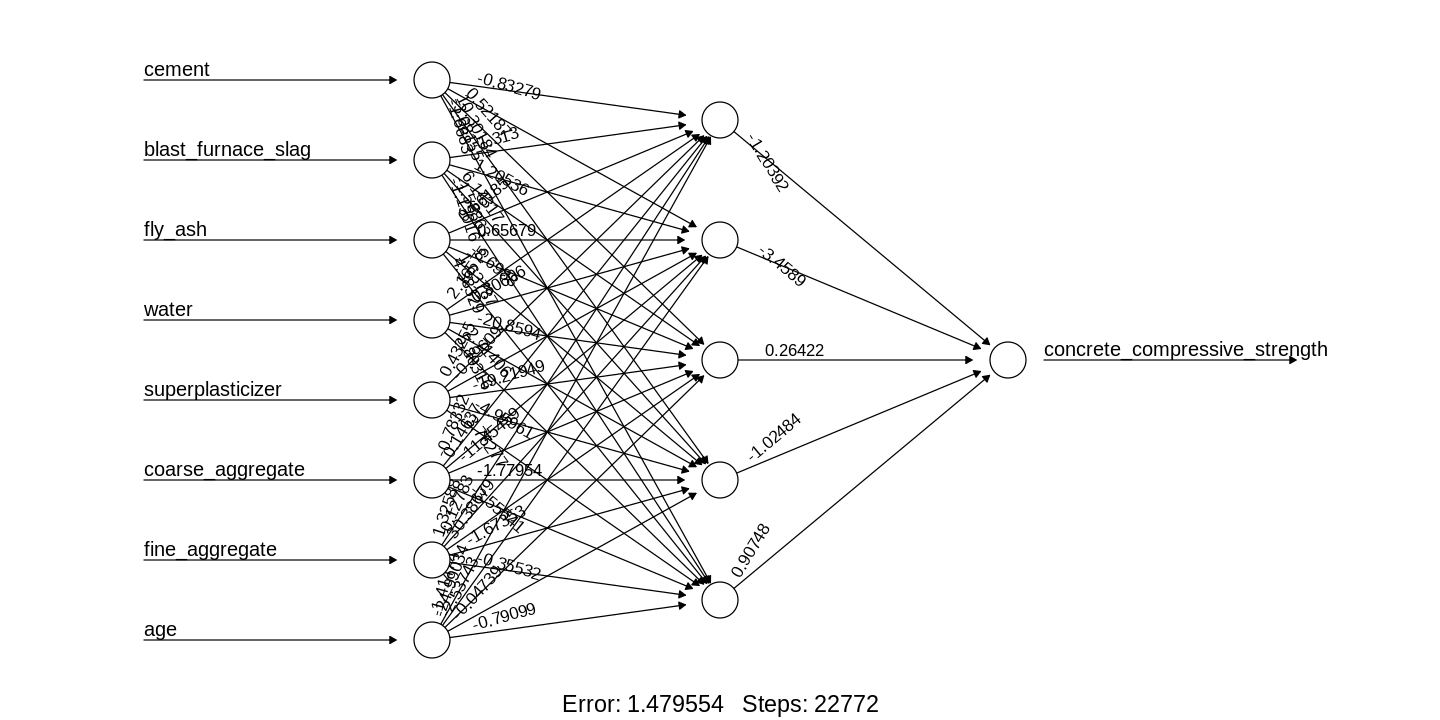

In [36]:
concrete_model2 <- neuralnet(concrete_compressive_strength ~ cement + blast_furnace_slag + fly_ash + water + superplasticizer + coarse_aggregate + fine_aggregate + age, data = concrete_train, hidden = 5)
# Set plot size for inline display
options(repr.plot.width = 12, repr.plot.height = 6)

plot(concrete_model2,
     rep = "best",         # Plots the best repetition if multiple were trained
     intercept = FALSE,    # Removes bias nodes if you want a simpler view
     show.weights = TRUE,  # Displays weights on the connections
     information = TRUE)   # Adds additional training info in the plot


the reported error (SSE) has been reduced from 5.666 to 1.48

In [37]:
model_results2 <- compute(concrete_model2, concrete_test[1:8])
predicted_strength2 <- model_results2$net.result
cor(predicted_strength2, concrete_test$concrete_compressive_strength)

0.7398468


There is also an improvement in the correlation from 0.72 to 0.74